<h1 align="center">
  <span style="background: linear-gradient(90deg, #ff6ec4, #7873f5); 
               -webkit-background-clip: text; 
               -webkit-text-fill-color: transparent;">
    BOSTON HOUSING DATASET
  </span>
</h1>


---

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter  
from torch.utils.data import random_split
from torch.utils.data import Dataset

In [9]:

from random import sample


class HousingDataset(Dataset):
    def __init__(self, src_file, root_dir, transform=None):
        #CARGA DE DATOS
        # ponbemos las col del datas
        housingDataset = pd.read_csv(src_file, sep=r"\s+", header=None, 
                                    names=["CRIM","ZN","INDUS","CHAS","NOX","RM","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV","class"])
        
        # TEST X e Y
        # X = Las características de la casa (habitaciones, impuestos, etc.)
        X = housingDataset[housingDataset.columns.intersection(["CRIM","ZN","INDUS","CHAS","NOX","RM","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"])]
        
        # Y = La clase de la casa (lo que queremos predecir)
        Y = housingDataset[housingDataset.columns.intersection(["class"])]
        
        # TRANSFORMACIÓN DE LAS CLASES -> CON ONE HOT ENCODING
        # vemos cuantas clases hay unicas 
        nomeClases = Y["class"].unique()
        YConversion = pd.DataFrame()
        
        # Por cada clase unica, creamos una columna llena de 1.0 (si pertenece) o 0.0 (si no).
        for nome in nomeClases:
            YConversion[nome] = (Y["class"] == nome).apply(lambda x : 1.0 if x else 0.0)

        # Convertimos esa tabla de 1s y 0s en un Tensor de PyTorch (formato decimal).
        y_tensor = torch.as_tensor(YConversion.to_numpy(), dtype=torch.float32)
        
        # preparacion de la features x
        # solo los números de las primeras 13 columnas.
        s1 = X.iloc[:, 0:13].values
        x_tensor = torch.tensor(s1, dtype=torch.float32) 
        
        # ESCALAR LOS DATOS
        scaler = StandardScaler()
        XScalada = torch.tensor(scaler.fit_transform(x_tensor), dtype=torch.float32)
        
        # Juntamos la X (escalada) y la Y (1s y 0s) en una sola tabla grande llamada self.data
        self.data = torch.cat((XScalada, y_tensor), 1)
        
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
    # Si le piden los datos en formato tensor, convierte el índice a un número normal.
        if torch.is_tensor(idx):
            idx = idx.tolist()
    
    # Va a la fila pedida (idx) y toma las primeras 13 columnas 
        preds = self.data[idx, 0:13]
    
    # Va a la misma fila y toma desde la columna 13 en adelante (la clase en 1s y 0s)
        spcs = self.data[idx, 13:]
    
    # Empaqueta ambos pedazos juntos
        sample = (preds, spcs)
    
    # Si le dijimos que aplicara alguna transformación extra (imágenes, etc.), lo hace aquí.
        if self.transform:
            sample = self.transform(sample)

        return sample

In [10]:
dataset = HousingDataset("../../docs/housing/housing.data",".")
display(dataset[0]) 

/tmp/ipykernel_17325/1436692011.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  YConversion[nome] = (Y["class"] == nome).apply(lambda x : 1.0 if x else 0.0)


(tensor([-0.4198,  0.2848, -1.2879, -0.2726, -0.1442,  0.4137, -0.1200,  0.1402,
         -0.9828, -0.6666, -1.4590,  0.4411, -1.0756]),
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [11]:
datasetLength = len(dataset)

tamTrain = int(datasetLength * 0.8)
tamVal = datasetLength - tamTrain  # así evitamos errores de redondeo

print(f"Tam dataset: {datasetLength} train: {tamTrain} val: {tamVal}")

train_set, val_set = random_split(dataset, [tamTrain, tamVal])

train_ldr = torch.utils.data.DataLoader(train_set, batch_size=2, shuffle=True, drop_last=False)

validation_loader = torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)

Tam dataset: 506 train: 404 val: 102


In [12]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(50, 1)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [13]:
model     = Model(13)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()
display(model)

Model(
  (layer1): Linear(in_features=13, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=1, bias=True)
)

In [14]:
entradaProba,dest = next(iter(train_ldr))
print("Entrada:")
display(entradaProba)
print("Desexada:")
display(dest)
saida = model(entradaProba) # esta é a proba de verdade
print("Saída:")
display(saida)
loss_fn(saida, dest)

Entrada:


tensor([[-0.3904, -0.4877,  1.5690, -0.2726,  0.5987, -0.8429,  0.9753, -0.9539,
         -0.6380,  0.1708,  1.2689,  0.3885,  0.6360],
        [ 1.0693, -0.4877,  1.0160, -0.2726,  1.6007, -0.6135,  0.9966, -0.9029,
          1.6612,  1.5309,  0.8066, -1.2736,  1.5611]])

Desexada:


tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0.,

Saída:


tensor([[-0.1000],
        [-0.1479]], grad_fn=<AddmmBackward0>)

/media/a22nicolesdc/DIURNOEXTRA/programacion/pytorch-1/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2, 229])) that is different to the input size (torch.Size([2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(0.0214, grad_fn=<MseLossBackward0>)

In [15]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    # usamos enumerate para saber en que batch imos
    for i, data in enumerate(train_ldr):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

In [16]:
EPOCHS = 100
loss_list     = torch.zeros((EPOCHS,))
accuracy_list = torch.zeros((EPOCHS,))

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # Poñemos o modelo en modo entrenamento
    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss
    # Non se precisan os gradientes para o test
    model.train(False)

EPOCH 1:
  batch 10 loss: 0.009200874483212829
  batch 20 loss: 0.005536148138344288
  batch 30 loss: 0.007679885113611817
  batch 40 loss: 0.006031295331194997
  batch 50 loss: 0.005667824810370803
  batch 60 loss: 0.0055065630469471214
  batch 70 loss: 0.004713935730978847
  batch 80 loss: 0.005060616275295615
  batch 90 loss: 0.005645628599449992
  batch 100 loss: 0.004956737672910094
  batch 110 loss: 0.005516447313129902
  batch 120 loss: 0.005232167895883322
  batch 130 loss: 0.004735105484724045
  batch 140 loss: 0.0050963439047336575
  batch 150 loss: 0.004844233812764287
  batch 160 loss: 0.004739233758300543
  batch 170 loss: 0.004669409990310669
  batch 180 loss: 0.004840322071686387
  batch 190 loss: 0.005011314246803522
  batch 200 loss: 0.0050461901351809505
EPOCH 2:
  batch 10 loss: 0.004600572446361184
  batch 20 loss: 0.004545492865145206
  batch 30 loss: 0.004683625511825084
  batch 40 loss: 0.004561807261779904
  batch 50 loss: 0.004953500861302018
  batch 60 loss: 0

In [17]:
running_vloss = 0.0
for i, vdata in enumerate(validation_loader):
    vinputs, vlabels = vdata
    voutputs = model(vinputs)
    vloss = loss_fn(voutputs, vlabels)
    running_vloss += vloss

avg_vloss = running_vloss / (i + 1)
print(f'LOSS train {avg_loss:.4f} valid {avg_vloss:.4f}')

LOSS train 0.0043 valid 0.0043


/media/a22nicolesdc/DIURNOEXTRA/programacion/pytorch-1/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([4, 229])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Text(0.5, 0, 'epochs')

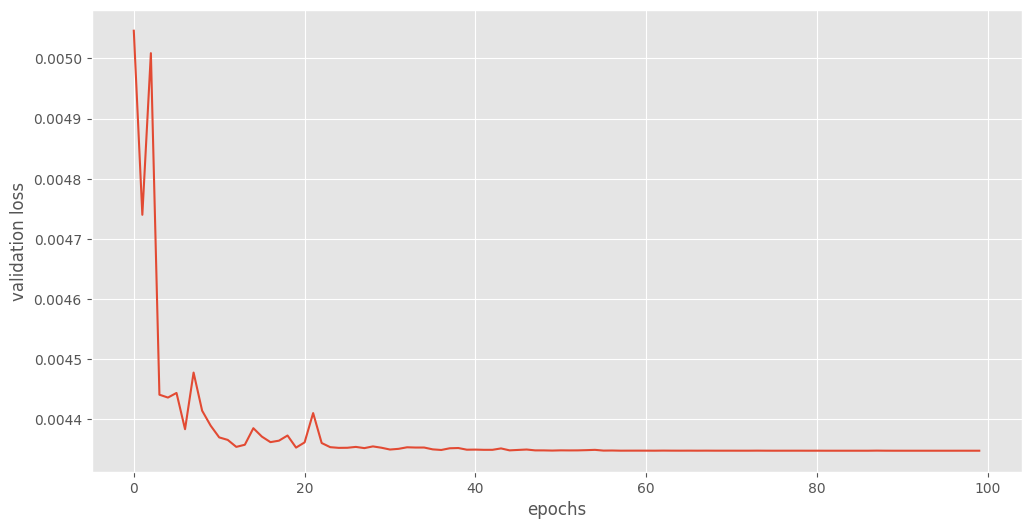

In [18]:
plt.style.use('ggplot')
fig, (ax2) = plt.subplots(1, figsize=(12, 6), sharex=True)
ax2.plot(loss_list)
ax2.set_ylabel("validation loss")
ax2.set_xlabel("epochs")